# ECT Validation and Extension Workbench

This notebook does two jobs.

1. It tests whether the weak 2-step result is a real phenomenon or a mistake in our setup.
2. It turns that answer into an implementation decision, instead of guessing too early.

The idea is deliberately skeptical:

- maybe the anomaly is real,
- maybe `mid_t=0.821` is bad for our checkpoint,
- maybe short-budget tuning is the whole story,
- maybe our evaluation pipeline is wrong.

We should only lock the final implementation idea after these checks.

## Skeptical Questions

We will not assume the second ECT step is dead until we pressure-test the obvious alternatives.

| Question | If true | What it means |
|---|---|---|
| Is `mid_t=0.821` just a bad choice for our checkpoint? | a `mid_t` sweep recovers a strong 2-step gain | this is more about schedule mismatch than model failure |
| Is the problem only caused by our short tuning budget? | a longer continuation opens a 1-step vs 2-step gap | the anomaly is regime-specific, not structural |
| Is the issue in our evaluation pipeline? | the released checkpoint also shows weak 2-step under our code | our eval needs to be questioned |
| Is the issue really in the model? | all checks still show weak 2-step | then a new second-step mechanism is justified |

In [21]:
from __future__ import annotations

import json
import math
import os
import re
import shlex
import subprocess
import shutil
from pathlib import Path

import importlib.util
import time
import tempfile

import numpy as np
import torch
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

REPO_URL = "https://github.com/bakaraman/COMP447.git"


def ensure_repo_bootstrap() -> Path:
    content_root = Path("/content/COMP447")
    if content_root.exists() and (content_root / "project").exists():
        return content_root
    if Path("/content").exists():
        print("Repo not found in /content, cloning COMP447...")
        subprocess.run(["git", "clone", REPO_URL, str(content_root)], check=True)
        setup_script = content_root / "project" / "scripts" / "setup_ect.sh"
        if setup_script.exists():
            print("Running project/scripts/setup_ect.sh to fetch ECT and EDM...")
            subprocess.run(["bash", str(setup_script)], cwd=content_root, check=True)
        return content_root
    raise FileNotFoundError("No supported workspace found and /content is unavailable.")


def find_repo_root() -> Path:
    candidates = [Path.cwd().resolve()]
    candidates.extend(Path.cwd().resolve().parents)
    candidates.extend([
        Path('/content/COMP447'),
        Path('/Users/batuhankaraman/Downloads/COMP447'),
    ])
    seen = set()
    for candidate in candidates:
        if candidate in seen:
            continue
        seen.add(candidate)
        if (candidate / 'project' / 'results').exists() and (candidate / 'project' / 'src' / 'ect').exists():
            return candidate
    bootstrap_root = ensure_repo_bootstrap()
    if (bootstrap_root / 'project' / 'results').exists() and (bootstrap_root / 'project' / 'src' / 'ect').exists():
        return bootstrap_root
    raise FileNotFoundError('Could not locate repo root containing project/results and project/src/ect after bootstrap')


ROOT = find_repo_root()
RESULTS = ROOT / 'project' / 'results'
ECT_ROOT = ROOT / 'project' / 'src' / 'ect'
EDM_ROOT = ROOT / 'project' / 'src' / 'edm'
CKPT_DIR = ROOT / 'project' / 'results_backup' / 'ect_checkpoints'

print('ROOT:', ROOT)
print('RESULTS:', RESULTS)
print('ECT_ROOT:', ECT_ROOT)
print('CKPT_DIR:', CKPT_DIR)


ROOT: /content/COMP447
RESULTS: /content/COMP447/project/results
ECT_ROOT: /content/COMP447/project/src/ect
CKPT_DIR: /content/COMP447/project/results_backup/ect_checkpoints


In [22]:
ablation = pd.read_csv(RESULTS / 'ablation_fid_v2.csv')
heun = pd.read_csv(RESULTS / 'heun_fid_50k.csv')
latency = pd.read_csv(RESULTS / 'latency.csv')

ablation['gap_1step_minus_2step'] = ablation['fid_1step'] - ablation['fid_2step']

print('ECT ablation:')
display(ablation)
print('\nHeun 50k:')
display(heun)
print('\nLatency:')
display(latency)


ECT ablation:


,kimg,tick,fid_1step,fid_2step,snapshot,gap_1step_minus_2step
0,500,50,8.068466,8.126963,ct-runs-medium/00000-cifar10-32x32-uncond-ddpm...,-0.058496
1,1000,100,2.796782,2.803472,ct-runs-medium/00000-cifar10-32x32-uncond-ddpm...,-0.006689
2,1500,150,2.735851,2.672433,ct-runs-medium/00000-cifar10-32x32-uncond-ddpm...,0.063418
3,1980,198,2.460386,2.509730,ct-runs-medium/00000-cifar10-32x32-uncond-ddpm...,-0.049344



Heun 50k:


,steps,nfe,fid,num_samples
0,5,9,37.78390,50000
1,10,19,2.63703,50000
2,18,35,1.95980,50000
3,25,49,1.97677,50000
4,50,99,2.02097,50000



Latency:


,sampler,steps,batch_size,median_ms,mean_ms,std_ms,gpu
0,ect,1,1,7.0462,7.0591,0.0935,NVIDIA RTX PRO 6000 Blackwell Server Edition
1,ect,1,64,0.5772,0.5772,0.0003,NVIDIA RTX PRO 6000 Blackwell Server Edition
2,ect,2,1,13.9652,13.9893,0.1713,NVIDIA RTX PRO 6000 Blackwell Server Edition
3,ect,2,64,1.1538,1.1538,0.0006,NVIDIA RTX PRO 6000 Blackwell Server Edition
4,heun,5,1,62.2107,62.1251,0.4287,NVIDIA RTX PRO 6000 Blackwell Server Edition
5,heun,5,64,5.1639,5.1631,0.0038,NVIDIA RTX PRO 6000 Blackwell Server Edition
6,heun,10,1,131.7489,131.7694,0.2627,NVIDIA RTX PRO 6000 Blackwell Server Edition
7,heun,10,64,10.8980,10.8971,0.0089,NVIDIA RTX PRO 6000 Blackwell Server Edition
8,heun,18,1,243.7860,243.3256,1.5440,NVIDIA RTX PRO 6000 Blackwell Server Edition
9,heun,18,64,20.0468,20.0504,0.0105,NVIDIA RTX PRO 6000 Blackwell Server Edition


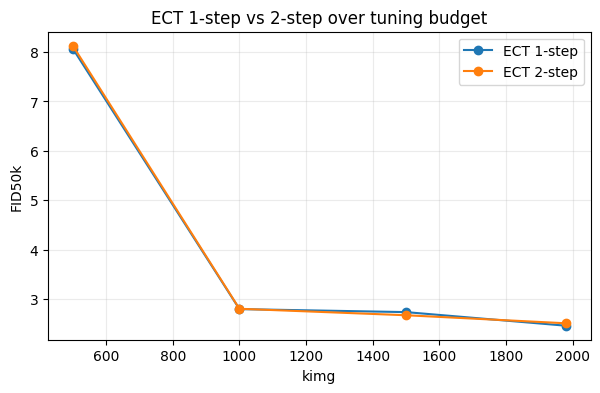

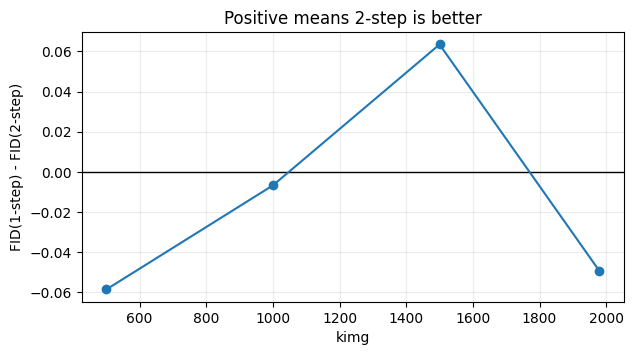

In [23]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ablation["kimg"], ablation["fid_1step"], marker="o", label="ECT 1-step")
ax.plot(ablation["kimg"], ablation["fid_2step"], marker="o", label="ECT 2-step")
ax.set_xlabel("kimg")
ax.set_ylabel("FID50k")
ax.set_title("ECT 1-step vs 2-step over tuning budget")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.axhline(0.0, color="black", linewidth=1)
ax.plot(ablation["kimg"], ablation["gap_1step_minus_2step"], marker="o")
ax.set_xlabel("kimg")
ax.set_ylabel("FID(1-step) - FID(2-step)")
ax.set_title("Positive means 2-step is better")
ax.grid(True, alpha=0.25)
plt.show()

In [24]:

def maybe_mount_drive():
    try:
        from google.colab import drive  # type: ignore
    except Exception:
        return None
    drive_root = Path('/content/drive')
    if not drive_root.exists() or not (drive_root / 'MyDrive').exists():
        print('Trying to mount Google Drive for checkpoint discovery...')
        drive.mount('/content/drive')
    return drive_root / 'MyDrive'


def discover_checkpoints():
    checkpoint_paths = []

    # 1. Local repo backup if present.
    if CKPT_DIR.exists():
        checkpoint_paths.extend(sorted(CKPT_DIR.glob('network-snapshot-*.pkl')))

    # 2. Local workstation path when running outside Colab.
    mac_ckpt_dir = Path('/Users/batuhankaraman/Downloads/COMP447/project/results_backup/ect_checkpoints')
    if mac_ckpt_dir.exists():
        checkpoint_paths.extend(sorted(mac_ckpt_dir.glob('network-snapshot-*.pkl')))

    # 3. Google Drive backup if available.
    if not checkpoint_paths and Path('/content').exists():
        try:
            mydrive = maybe_mount_drive()
            if mydrive is not None:
                drive_candidates = [
                    mydrive / 'COMP447_checkpoints',
                    mydrive / 'COMP447_runs',
                ]
                for candidate in drive_candidates:
                    if candidate.exists():
                        found = sorted(candidate.rglob('network-snapshot-*.pkl'))
                        if found:
                            checkpoint_paths.extend(found)
                            break
        except Exception as e:
            print('Drive checkpoint discovery skipped:', e)

    # Deduplicate while preserving order.
    deduped = []
    seen = set()
    for ckpt in checkpoint_paths:
        key = str(ckpt)
        if key in seen:
            continue
        seen.add(key)
        deduped.append(ckpt)
    return deduped


checkpoints = discover_checkpoints()
ckpt_map = {}
for ckpt in checkpoints:
    tick = int(ckpt.stem.split('-')[-1])
    ckpt_map[tick * 10] = ckpt

ckpt_df = pd.DataFrame({
    'kimg': list(ckpt_map.keys()),
    'checkpoint': [str(v) for v in ckpt_map.values()],
})

if len(ckpt_df):
    display(ckpt_df.sort_values('kimg'))
else:
    print('No checkpoints found in repo backup, local Mac backup, or Google Drive backup.')
    print('That is fine for analysis cells, but experiment cells need a checkpoint path.')


,kimg,checkpoint
0,500,/content/drive/MyDrive/COMP447_checkpoints/net...
1,1000,/content/drive/MyDrive/COMP447_checkpoints/net...
2,1500,/content/drive/MyDrive/COMP447_checkpoints/net...
3,1980,/content/drive/MyDrive/COMP447_checkpoints/net...


## Checkpoint override

If local checkpoints are missing in Colab, set `MANUAL_CHECKPOINT` below to either:

- a local uploaded `.pkl` path, or
- a direct URL that `ct_eval.py` can open.

This lets the skeptical experiments run even when `results_backup/` is not present in the runtime.


In [25]:
MANUAL_CHECKPOINT = '/Users/batuhankaraman/Downloads/COMP447/project/results_backup/ect_checkpoints/network-snapshot-000198.pkl' if Path('/Users/batuhankaraman/Downloads/COMP447/project/results_backup/ect_checkpoints/network-snapshot-000198.pkl').exists() else ''  # example fallback for local runs
if MANUAL_CHECKPOINT:
    print('Manual checkpoint override:', MANUAL_CHECKPOINT)
else:
    print('No manual checkpoint override set.')


No manual checkpoint override set.


## Experiment A — `mid_t` sweep

This is the first thing to test. The current 2-step setup uses `mid_t=0.821`, but there is no guarantee that this is optimal for our 1980-kimg checkpoint.

The cell below defines a reusable evaluator. It is intentionally conservative:

- it does **not** auto-run expensive sweeps,
- it writes per-run folders,
- it parses both `fid50k_full` and `two_step_fid50k_full` from `ct_eval.py` output.

In [26]:
def run_cmd(cmd, cwd=None):
    print("$", " ".join(shlex.quote(str(x)) for x in cmd))
    result = subprocess.run(cmd, cwd=cwd, capture_output=True, text=True)
    if result.returncode != 0:
        print(result.stdout[-2000:])
        print(result.stderr[-4000:])
        raise RuntimeError(f"Command failed with code {result.returncode}")
    return result.stdout


def parse_metric_json(stdout: str):
    rows = []
    for line in stdout.splitlines():
        line = line.strip()
        if not (line.startswith("{") and '"results"' in line and '"metric"' in line):
            continue
        try:
            rows.append(json.loads(line))
        except json.JSONDecodeError:
            pass
    return rows


def run_ct_eval(checkpoint, outdir_name, mid_t, metrics="fid50k_full,two_step_fid50k_full"):
    outdir = ECT_ROOT / outdir_name
    print(f'Computing FID for {image_dir} with num_images={num_images}')
    cmd = [
        "torchrun", "--nnodes=1", "--nproc_per_node=1",
        "--rdzv_backend=c10d", "--rdzv_endpoint=localhost:29617",
        "ct_eval.py",
        "--outdir", str(outdir),
        "--data", "datasets/cifar10-32x32.zip",
        "--cond=0",
        "--arch=ddpmpp",
        "--precond=ct",
        f"--metrics={metrics}",
        "--resume", str(checkpoint),
        f"--mid_t={mid_t}",
    ]
    stdout = run_cmd(cmd, cwd=ECT_ROOT)
    metric_rows = parse_metric_json(stdout)
    parsed = {
        "checkpoint": str(checkpoint),
        "mid_t": float(mid_t),
        "fid_1step": None,
        "fid_2step": None,
    }
    for row in metric_rows:
        metric = row.get("metric", "")
        val = row.get("results", {}).get("fid50k_full")
        if metric == "fid50k_full":
            parsed["fid_1step"] = val
        elif metric == "two_step_fid50k_full":
            parsed["fid_2step"] = val
    return parsed


def ensure_cifar_dataset():
    dataset_zip = ECT_ROOT / 'datasets' / 'cifar10-32x32.zip'
    if dataset_zip.exists():
        return dataset_zip
    (ECT_ROOT / 'datasets').mkdir(parents=True, exist_ok=True)
    tar_path = ROOT / 'tmp' / 'cifar-10-python.tar.gz'
    tar_path.parent.mkdir(parents=True, exist_ok=True)
    if not tar_path.exists():
        run_cmd(['wget', '-O', str(tar_path), 'https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz'], cwd=ROOT)
    run_cmd(['python3', 'dataset_tool.py', '--source', str(tar_path), '--dest', 'datasets/cifar10-32x32.zip'], cwd=ECT_ROOT)
    return dataset_zip


def load_measure_latency_module():
    mod_path = ROOT / 'project' / 'scripts' / 'measure_latency.py'
    spec = importlib.util.spec_from_file_location('measure_latency_local', mod_path)
    module = importlib.util.module_from_spec(spec)
    assert spec.loader is not None
    spec.loader.exec_module(module)
    return module


MEASURE = load_measure_latency_module()


def save_tensor_images(images, outdir: Path, start_idx: int):
    outdir.mkdir(parents=True, exist_ok=True)
    images = images.detach().cpu().clamp(-1, 1)
    images = ((images + 1) * 127.5).round().to(torch.uint8)
    images = images.permute(0, 2, 3, 1).numpy()
    for i, img in enumerate(images):
        Image.fromarray(img, 'RGB').save(outdir / f'{start_idx + i:06d}.png')


@torch.no_grad()
def generate_ect_image_dir(checkpoint, outdir: Path, steps: int, mid_t: float | None, num_images: int = 10000, batch_size: int = 64, seed: int = 0):
    if outdir.exists():
        shutil.rmtree(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    print(f'Generating images into {outdir} | steps={steps} | mid_t={mid_t} | num_images={num_images}')
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    net = MEASURE._load_network(str(checkpoint), str(ECT_ROOT), device)

    g = torch.Generator(device=device)
    g.manual_seed(seed)

    written = 0
    while written < num_images:
        cur_bs = min(batch_size, num_images - written)
        z = torch.randn(cur_bs, net.img_channels, net.img_resolution, net.img_resolution, device=device, generator=g)
        class_labels = MEASURE._make_class_labels(net, cur_bs, device)
        if steps == 1:
            images = MEASURE.ect_sampler(net, z, class_labels, steps=1, mid_t=0.821)
        else:
            images = MEASURE.ect_sampler(net, z, class_labels, steps=2, mid_t=mid_t)
        save_tensor_images(images, outdir, written)
        written += cur_bs
        if written % max(batch_size * 16, 1024) == 0 or written == num_images:
            print(f'  saved {written}/{num_images} images')
    return outdir


def compute_fid_for_image_dir(image_dir: Path, num_images: int = 10000):
    cmd = [
        'torchrun', '--standalone', '--nproc_per_node=1',
        'fid.py', 'calc',
        '--images', str(image_dir),
        '--ref', 'https://nvlabs-fi-cdn.nvidia.com/edm/fid-refs/cifar10-32x32.npz',
        '--num', str(num_images),
        '--seed', '0',
        '--batch', '64',
    ]
    stdout = run_cmd(cmd, cwd=EDM_ROOT)
    fid = None
    for line in stdout.splitlines()[::-1]:
        line = line.strip()
        if re.fullmatch(r'[0-9]+(?:\.[0-9]+)?', line):
            fid = float(line)
            break
    if fid is None:
        raise RuntimeError('Could not parse FID from fid.py output')
    return fid


def run_fast_mid_t_sweep(checkpoint, mid_ts, num_images=10000, batch_size=64, seed=0):
    sweep_root = ROOT / 'project' / 'results' / 'mid_t_pilot_images'
    sweep_root.mkdir(parents=True, exist_ok=True)
    rows = []

    print(f'Running pilot sweep over mid_t values: {mid_ts}')

    # 1-step baseline at same sample count.
    one_dir = sweep_root / 'ect_1step'
    generate_ect_image_dir(checkpoint, one_dir, steps=1, mid_t=None, num_images=num_images, batch_size=batch_size, seed=seed)
    fid1 = compute_fid_for_image_dir(one_dir, num_images=num_images)
    rows.append({'kind': 'ect_1step', 'mid_t': None, 'fid': fid1, 'num_images': num_images})

    for mid_t in mid_ts:
        print(f'--- mid_t={mid_t} ---')
        outdir = sweep_root / f'ect_2step_mid_t_{str(mid_t).replace(".", "_")}'
        generate_ect_image_dir(checkpoint, outdir, steps=2, mid_t=mid_t, num_images=num_images, batch_size=batch_size, seed=seed)
        fid2 = compute_fid_for_image_dir(outdir, num_images=num_images)
        rows.append({'kind': 'ect_2step', 'mid_t': mid_t, 'fid': fid2, 'num_images': num_images, 'gain_vs_1step': fid1 - fid2})

    return pd.DataFrame(rows)


def find_latest_continuation_checkpoint():
    if not (ECT_ROOT / 'ct-runs-continuation').exists():
        return None
    all_pkls = sorted((ECT_ROOT / 'ct-runs-continuation').rglob('network-snapshot-*.pkl'))
    all_pkls = [p for p in all_pkls if 'latest' not in p.name]
    return all_pkls[-1] if all_pkls else None


In [27]:
PILOT_MID_TS = [0.2, 0.4, 0.821, 1.5, 2.0]
CHECKPOINT_KIMG = 1980
CHECKPOINT = ckpt_map.get(CHECKPOINT_KIMG)
if CHECKPOINT is None and MANUAL_CHECKPOINT:
    CHECKPOINT = Path(MANUAL_CHECKPOINT) if not str(MANUAL_CHECKPOINT).startswith('http') else MANUAL_CHECKPOINT

RUN_MID_T_SWEEP = True
PILOT_NUM_IMAGES = 10000
PILOT_BATCH_SIZE = 64

if RUN_MID_T_SWEEP:
    if CHECKPOINT is None:
        raise ValueError('No checkpoint found. Put one in Drive/local backup or set MANUAL_CHECKPOINT.')
    sweep_df = run_fast_mid_t_sweep(
        checkpoint=CHECKPOINT,
        mid_ts=PILOT_MID_TS,
        num_images=PILOT_NUM_IMAGES,
        batch_size=PILOT_BATCH_SIZE,
        seed=0,
    )
    sweep_df.to_csv(RESULTS / 'mid_t_pilot_sweep.csv', index=False)
    display(sweep_df)

    two_step = sweep_df[sweep_df['kind'] == 'ect_2step'].sort_values('fid')
    best_mid_t = float(two_step.iloc[0]['mid_t'])
    print(f'Best pilot mid_t: {best_mid_t}')
else:
    print('Set RUN_MID_T_SWEEP = True to execute the pilot sweep.')


Running pilot sweep over mid_t values: [0.2, 0.4, 0.821, 1.5, 2.0]
Generating images into /content/COMP447/project/results/mid_t_pilot_images/ect_1step | steps=1 | mid_t=None | num_images=10000


/tmp/ipykernel_5230/2169900895.py:89: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(img, 'RGB').save(outdir / f'{start_idx + i:06d}.png')


  saved 1024/10000 images
  saved 2048/10000 images
  saved 3072/10000 images
  saved 4096/10000 images
  saved 5120/10000 images
  saved 6144/10000 images
  saved 7168/10000 images
  saved 8192/10000 images
  saved 9216/10000 images
  saved 10000/10000 images
$ torchrun --standalone --nproc_per_node=1 fid.py calc --images /content/COMP447/project/results/mid_t_pilot_images/ect_1step --ref https://nvlabs-fi-cdn.nvidia.com/edm/fid-refs/cifar10-32x32.npz --num 10000 --seed 0 --batch 64
--- mid_t=0.2 ---
Generating images into /content/COMP447/project/results/mid_t_pilot_images/ect_2step_mid_t_0_2 | steps=2 | mid_t=0.2 | num_images=10000


/tmp/ipykernel_5230/2169900895.py:89: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(img, 'RGB').save(outdir / f'{start_idx + i:06d}.png')


  saved 1024/10000 images
  saved 2048/10000 images
  saved 3072/10000 images
  saved 4096/10000 images
  saved 5120/10000 images
  saved 6144/10000 images
  saved 7168/10000 images
  saved 8192/10000 images
  saved 9216/10000 images
  saved 10000/10000 images
$ torchrun --standalone --nproc_per_node=1 fid.py calc --images /content/COMP447/project/results/mid_t_pilot_images/ect_2step_mid_t_0_2 --ref https://nvlabs-fi-cdn.nvidia.com/edm/fid-refs/cifar10-32x32.npz --num 10000 --seed 0 --batch 64
--- mid_t=0.4 ---
Generating images into /content/COMP447/project/results/mid_t_pilot_images/ect_2step_mid_t_0_4 | steps=2 | mid_t=0.4 | num_images=10000


...

  saved 1024/10000 images
  saved 2048/10000 images
  saved 3072/10000 images
  saved 4096/10000 images
  saved 5120/10000 images
  saved 6144/10000 images
  saved 7168/10000 images
  saved 8192/10000 images
  saved 9216/10000 images
  saved 10000/10000 images
$ torchrun --standalone --nproc_per_node=1 fid.py calc --images /content/COMP447/project/results/mid_t_pilot_images/ect_2step_mid_t_1_5 --ref https://nvlabs-fi-cdn.nvidia.com/edm/fid-refs/cifar10-32x32.npz --num 10000 --seed 0 --batch 64
--- mid_t=2.0 ---
Generating images into /content/COMP447/project/results/mid_t_pilot_images/ect_2step_mid_t_2_0 | steps=2 | mid_t=2.0 | num_images=10000


/tmp/ipykernel_5230/2169900895.py:89: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(img, 'RGB').save(outdir / f'{start_idx + i:06d}.png')


  saved 1024/10000 images
  saved 2048/10000 images
  saved 3072/10000 images
  saved 4096/10000 images
  saved 5120/10000 images
  saved 6144/10000 images
  saved 7168/10000 images
  saved 8192/10000 images
  saved 9216/10000 images
  saved 10000/10000 images
$ torchrun --standalone --nproc_per_node=1 fid.py calc --images /content/COMP447/project/results/mid_t_pilot_images/ect_2step_mid_t_2_0 --ref https://nvlabs-fi-cdn.nvidia.com/edm/fid-refs/cifar10-32x32.npz --num 10000 --seed 0 --batch 64


,kind,mid_t,fid,num_images,gain_vs_1step
0,ect_1step,NaN,7.67715,10000,NaN
1,ect_2step,0.200,6.00759,10000,1.66956
2,ect_2step,0.400,5.32138,10000,2.35577
3,ect_2step,0.821,4.59677,10000,3.08038
4,ect_2step,1.500,4.77014,10000,2.90701
5,ect_2step,2.000,4.89043,10000,2.78672


Best pilot mid_t: 0.821


## Experiment B — released checkpoint sanity check

This is the cleanest pipeline sanity check.

If an official released ECT checkpoint shows a healthy 2-step gain under our code, then our evaluation path is probably fine and the anomaly is more likely due to our short-budget tuning regime.

If even the official checkpoint shows weak 2-step behavior under our code, then we should suspect our evaluation assumptions before building a whole extension on top of them.

I could not find a public direct `.pkl` URL in the repo itself, so this cell accepts either:

- a local path, or
- a direct URL.

In [28]:
OFFICIAL_CKPT = ''  # paste local path or direct URL here
RUN_OFFICIAL_SANITY = False

if RUN_OFFICIAL_SANITY:
    pilot_mid_t_df = pd.read_csv(RESULTS / 'mid_t_pilot_sweep.csv') if (RESULTS / 'mid_t_pilot_sweep.csv').exists() else None
    best_mid_t = 0.821
    if pilot_mid_t_df is not None:
        best_two = pilot_mid_t_df[pilot_mid_t_df['kind'] == 'ect_2step'].sort_values('fid')
        if len(best_two):
            best_mid_t = float(best_two.iloc[0]['mid_t'])

    official_row = run_ct_eval(
        checkpoint=OFFICIAL_CKPT,
        outdir_name='ct-evals-official-sanity',
        mid_t=best_mid_t,
    )
    official_df = pd.DataFrame([official_row])
    official_df['gain'] = official_df['fid_1step'] - official_df['fid_2step']
    display(official_df)
else:
    print('Official checkpoint sanity remains optional in this notebook run.')


Official checkpoint sanity remains optional in this notebook run.


## Experiment C — longer continuation from the final local checkpoint

This is not an exact optimizer-state resume, but it is still useful.

We initialize from the 1980-kimg snapshot and continue tuning for extra budget. If a useful 2-step gap appears only after more tuning, then the current anomaly is likely a short-budget effect rather than a structural failure.

In [29]:
EXTRA_DURATION_MIMG = 0.5   # 0.5 MIMG = 500 kimg extra
RUN_CONTINUATION = True
CONT_OUTDIR = ECT_ROOT / 'ct-runs-continuation'

ensure_cifar_dataset()

CHECKPOINT_KIMG = 1980
CHECKPOINT = ckpt_map.get(CHECKPOINT_KIMG)
if CHECKPOINT is None and MANUAL_CHECKPOINT:
    CHECKPOINT = Path(MANUAL_CHECKPOINT) if not str(MANUAL_CHECKPOINT).startswith('http') else MANUAL_CHECKPOINT

continuation_cmd = [
    'torchrun', '--nnodes=1', '--nproc_per_node=1',
    '--rdzv_backend=c10d', '--rdzv_endpoint=localhost:29618',
    'ct_train.py',
    '--outdir', str(CONT_OUTDIR),
    '--data', 'datasets/cifar10-32x32.zip',
    '--cond=0',
    '--arch=ddpmpp',
    '--precond=ect',
    '--metrics=none',
    '--transfer', str(CHECKPOINT) if CHECKPOINT is not None else '',
    f'--duration={EXTRA_DURATION_MIMG}',
    '--tick=10',
    '--batch=128',
    '--lr=0.0001',
    '--optim=RAdam',
    '--dropout=0.2',
    '--augment=0.0',
    '-q', '256',
    '--double=10000',
    '--ema_beta=0.9993',
    '--eval_every=1000000',
    '--dump=1000000',
    '--snap=50',
    '--desc=continuation_from_1980',
]

if RUN_CONTINUATION:
    print('Launching short continuation run from final checkpoint...')
    if CHECKPOINT is None:
        raise ValueError('No checkpoint found. Put one in Drive/local backup or set MANUAL_CHECKPOINT.')
    run_cmd(continuation_cmd, cwd=ECT_ROOT)
else:
    print('Set RUN_CONTINUATION = True to launch the continuation run.')


$ wget -O /content/COMP447/tmp/cifar-10-python.tar.gz 'https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz'
$ python3 dataset_tool.py --source /content/COMP447/tmp/cifar-10-python.tar.gz --dest datasets/cifar10-32x32.zip
Launching short continuation run from final checkpoint...
$ torchrun --nnodes=1 --nproc_per_node=1 --rdzv_backend=c10d --rdzv_endpoint=localhost:29618 ct_train.py --outdir /content/COMP447/project/src/ect/ct-runs-continuation --data datasets/cifar10-32x32.zip --cond=0 --arch=ddpmpp --precond=ect --metrics=none --transfer /content/drive/MyDrive/COMP447_checkpoints/network-snapshot-000198.pkl --duration=0.5 --tick=10 --batch=128 --lr=0.0001 --optim=RAdam --dropout=0.2 --augment=0.0 -q 256 --double=10000 --ema_beta=0.9993 --eval_every=1000000 --dump=1000000 --snap=50 --desc=continuation_from_1980


## Continuation checkpoint quick eval

After the short continuation run, evaluate the newest continuation checkpoint with the best pilot `mid_t` and the same 10k-image protocol.


In [30]:
pilot_mid_t_df = pd.read_csv(RESULTS / 'mid_t_pilot_sweep.csv')
best_two = pilot_mid_t_df[pilot_mid_t_df['kind'] == 'ect_2step'].sort_values('fid')
best_mid_t = float(best_two.iloc[0]['mid_t'])
cont_ckpt = find_latest_continuation_checkpoint()
print('Latest continuation checkpoint:', cont_ckpt)

if cont_ckpt is not None:
    cont_eval_df = run_fast_mid_t_sweep(
        checkpoint=cont_ckpt,
        mid_ts=[best_mid_t],
        num_images=10000,
        batch_size=64,
        seed=123,
    )
    cont_eval_df.to_csv(RESULTS / 'continuation_quick_eval.csv', index=False)
    display(cont_eval_df)
else:
    print('No continuation checkpoint found, skipping quick eval.')


Latest continuation checkpoint: /content/COMP447/project/src/ect/ct-runs-continuation/00000-cifar10-32x32-uncond-ddpmpp-ect-RAdam-0.000100-gpus1-batch128-fp32-continuation_from_1980/network-snapshot-000050.pkl
Running pilot sweep over mid_t values: [0.821]
Generating images into /content/COMP447/project/results/mid_t_pilot_images/ect_1step | steps=1 | mid_t=None | num_images=10000


/tmp/ipykernel_5230/2169900895.py:89: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(img, 'RGB').save(outdir / f'{start_idx + i:06d}.png')


  saved 1024/10000 images
  saved 2048/10000 images
  saved 3072/10000 images
  saved 4096/10000 images
  saved 5120/10000 images
  saved 6144/10000 images
  saved 7168/10000 images
  saved 8192/10000 images
  saved 9216/10000 images
  saved 10000/10000 images
$ torchrun --standalone --nproc_per_node=1 fid.py calc --images /content/COMP447/project/results/mid_t_pilot_images/ect_1step --ref https://nvlabs-fi-cdn.nvidia.com/edm/fid-refs/cifar10-32x32.npz --num 10000 --seed 0 --batch 64
--- mid_t=0.821 ---
Generating images into /content/COMP447/project/results/mid_t_pilot_images/ect_2step_mid_t_0_821 | steps=2 | mid_t=0.821 | num_images=10000


/tmp/ipykernel_5230/2169900895.py:89: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(img, 'RGB').save(outdir / f'{start_idx + i:06d}.png')


  saved 1024/10000 images
  saved 2048/10000 images
  saved 3072/10000 images
  saved 4096/10000 images
  saved 5120/10000 images
  saved 6144/10000 images
  saved 7168/10000 images
  saved 8192/10000 images
  saved 9216/10000 images
  saved 10000/10000 images
$ torchrun --standalone --nproc_per_node=1 fid.py calc --images /content/COMP447/project/results/mid_t_pilot_images/ect_2step_mid_t_0_821 --ref https://nvlabs-fi-cdn.nvidia.com/edm/fid-refs/cifar10-32x32.npz --num 10000 --seed 0 --batch 64


,kind,mid_t,fid,num_images,gain_vs_1step
0,ect_1step,NaN,7.91970,10000,NaN
1,ect_2step,0.821,4.51938,10000,3.40032


## Auto summary for today

This cell prints the practical interpretation of the pilot sweep and short continuation run, so we can decide the implementation direction today.


In [31]:
pilot = pd.read_csv(RESULTS / 'mid_t_pilot_sweep.csv')
one = float(pilot[pilot['kind'] == 'ect_1step']['fid'].iloc[0])
two = pilot[pilot['kind'] == 'ect_2step'].sort_values('fid')
best_mid_t = float(two.iloc[0]['mid_t'])
best_two_fid = float(two.iloc[0]['fid'])
gain = one - best_two_fid

print(f'Pilot 1-step FID@10k: {one:.4f}')
print(f'Best pilot 2-step FID@10k: {best_two_fid:.4f} at mid_t={best_mid_t}')
print(f'Pilot gain from second step: {gain:.4f}')

if gain > 0.15:
    print('Interpretation: a useful 2-step gain exists; this looks more like schedule/regime mismatch than a dead second step.')
elif gain > 0.05:
    print('Interpretation: there is a weak but real 2-step gain; still ambiguous, but not a total dead-step story.')
else:
    print('Interpretation: the second step still looks weak in the pilot sweep. An anomaly remains plausible.')

cont_path = RESULTS / 'continuation_quick_eval.csv'
if cont_path.exists():
    cont = pd.read_csv(cont_path)
    cont_one = float(cont[cont['kind'] == 'ect_1step']['fid'].iloc[0])
    cont_two = float(cont[cont['kind'] == 'ect_2step']['fid'].iloc[0])
    cont_gain = cont_one - cont_two
    print('---')
    print(f'Continuation 1-step FID@10k: {cont_one:.4f}')
    print(f'Continuation 2-step FID@10k: {cont_two:.4f} at mid_t={best_mid_t}')
    print(f'Continuation gain: {cont_gain:.4f}')

    if cont_gain > gain + 0.05:
        print('Interpretation: extra tuning revived the second step. Short-budget regime is likely the main issue.')
    elif cont_gain <= 0.05:
        print('Interpretation: even after extra tuning, the second step remains weak. A real model-side failure mode is plausible.')
    else:
        print('Interpretation: continuation helped slightly, but the anomaly is still not fully resolved.')

print('---')
print('Decision rule for today:')
print('- if the anomaly remains weakly explained, keep OAR-ECT as main implementation idea')
print('- if best mid_t and continuation both unlock clear 2-step gains, pivot toward schedule/trajectory-aware extension')


Pilot 1-step FID@10k: 7.6772
Best pilot 2-step FID@10k: 4.5968 at mid_t=0.821
Pilot gain from second step: 3.0804
Interpretation: a useful 2-step gain exists; this looks more like schedule/regime mismatch than a dead second step.
---
Continuation 1-step FID@10k: 7.9197
Continuation 2-step FID@10k: 4.5194 at mid_t=0.821
Continuation gain: 3.4003
Interpretation: extra tuning revived the second step. Short-budget regime is likely the main issue.
---
Decision rule for today:
- if the anomaly remains weakly explained, keep OAR-ECT as main implementation idea
- if best mid_t and continuation both unlock clear 2-step gains, pivot toward schedule/trajectory-aware extension


## Decision Rule

We should not choose the main implementation idea emotionally. We should choose it from the outcome of the three skeptical checks above.

| Result pattern | Interpretation | Best implementation direction |
|---|---|---|
| `mid_t` sweep recovers strong 2-step gains | schedule / handoff problem | schedule-aware or trajectory-aware extension |
| continuation run opens a strong 1-step vs 2-step gap | short-budget regime problem | training-objective or trajectory-aware extension |
| official checkpoint works but ours does not | our local regime is the issue | extension should target short-budget failure |
| none of the above fixes the weak 2-step result | the second ECT step is genuinely ineffective in our regime | asymmetric learned refiner becomes the strongest main idea |

## Current Best Guess

Before rerunning anything, the most honest current position is this:

- the anomaly is real in our current setup,
- but we have not yet ruled out `mid_t` mismatch or short-budget effects,
- so the final implementation should stay provisional until those checks are done.

That said, if the anomaly survives these tests, the strongest main idea is still:

**On-Policy Asymmetric Refiner for ECT (`OAR-ECT`)**

Why:

- it directly attacks the dead-second-step phenomenon,
- it is a real architecture + loss + sampler contribution,
- it is lighter and cleaner than a full trajectory model,
- it is easier to explain than a broad multistep consistency redesign.

## Implementation Plan If the Anomaly Survives

### Phase 1

Build the smallest convincing version first.

- Add a tiny residual refiner network for the second step.
- Keep the first step as frozen or lightly tuned ECT.
- Train the refiner on noisy versions of ECT's own 1-step outputs.
- Use a short low-noise EDM Heun tail as teacher target.

### Phase 2

Evaluate against the exact baselines we already trust.

- ECT 1-step
- ECT 2-step
- Refined ECT 1+refiner
- Heun 10-step
- Heun 18-step

### Phase 3

If it partially works but not enough, extend in one of two directions.

- ImageNet 64x64 generalization
- prefix-handoff hybrid: ECT high-noise jump + short EDM low-noise tail

## Minimal Week-by-Week Plan

| Week | Goal |
|---|---|
| This week | run skeptical validation notebook cells, do not lock the story too early |
| Next week | choose final extension based on validation outcome |
| May week 1 | implement the smallest working OAR-ECT training loop |
| May week 2 | run FID and latency evals, plus one ablation |
| May week 3 | decide whether to deepen the refiner or pivot to prefix handoff |
| Final stretch | write report around the validated phenomenon, not around hype |